# Student Performance Prediction Using Deep Learning

This notebook preprocesses student data, trains a neural network, evaluates it, saves the model and preprocessing objects, and demonstrates user-input prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [2]:
df = pd.read_csv('student_performance_dataset.csv')
print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (5000, 15)


,Attendance_Percentage,Study_Hours_Per_Day,Previous_Semester_Marks,Assignments_Completed,Sleep_Hours,Internet_Access,Extra_Curricular_Activities,Parental_Education,Class_Participation,Mock_Tests_Attended,Disciplinary_Records,Family_Income,Distance_From_College_KM,Age,Final_Score
0,87.5,3.7,58.5,7,7.4,Yes,No,Diploma,6,4,0,Middle,9.3,20,96.5
1,80.5,3.7,63.7,7,7.3,No,Yes,Bachelor,6,5,0,Middle,18.2,22,83.0
2,89.1,1.3,59.6,8,6.0,Yes,Yes,Diploma,5,3,0,Low,12.9,20,94.4
3,98.8,3.9,69.5,9,7.6,Yes,No,Bachelor,5,1,0,Low,8.7,20,100.0
4,79.4,5.8,84.8,6,5.4,Yes,Yes,Bachelor,8,1,0,Low,7.5,20,96.3


In [3]:
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
display(df.describe(include='all').T)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Attendance_Percentage        5000 non-null   float64
 1   Study_Hours_Per_Day          5000 non-null   float64
 2   Previous_Semester_Marks      5000 non-null   float64
 3   Assignments_Completed        5000 non-null   int64  
 4   Sleep_Hours                  5000 non-null   float64
 5   Internet_Access              5000 non-null   str    
 6   Extra_Curricular_Activities  5000 non-null   str    
 7   Parental_Education           5000 non-null   str    
 8   Class_Participation          5000 non-null   int64  
 9   Mock_Tests_Attended          5000 non-null   int64  
 10  Disciplinary_Records         5000 non-null   int64  
 11  Family_Income                5000 non-null   str    
 12  Distance_From_College_KM     5000 non-null   float64
 13  Age                          

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Attendance_Percentage,5000.0,NaN,NaN,NaN,81.8322,10.482486,46.3,74.8,82.15,89.3,100.0
Study_Hours_Per_Day,5000.0,NaN,NaN,NaN,4.49078,1.795408,0.5,3.3,4.5,5.7,10.0
Previous_Semester_Marks,5000.0,NaN,NaN,NaN,68.10868,13.781247,30.0,58.7,68.1,77.5,100.0
Assignments_Completed,5000.0,NaN,NaN,NaN,7.4332,1.844402,0.0,6.0,8.0,9.0,10.0
Sleep_Hours,5000.0,NaN,NaN,NaN,6.97986,1.076996,4.0,6.2,7.0,7.7,10.0
Internet_Access,5000,2,Yes,4417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extra_Curricular_Activities,5000,2,No,2745,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Parental_Education,5000,4,Bachelor,1715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class_Participation,5000.0,NaN,NaN,NaN,6.9696,1.886422,0.0,6.0,7.0,8.0,10.0
Mock_Tests_Attended,5000.0,NaN,NaN,NaN,4.0398,1.967585,0.0,3.0,4.0,5.0,10.0


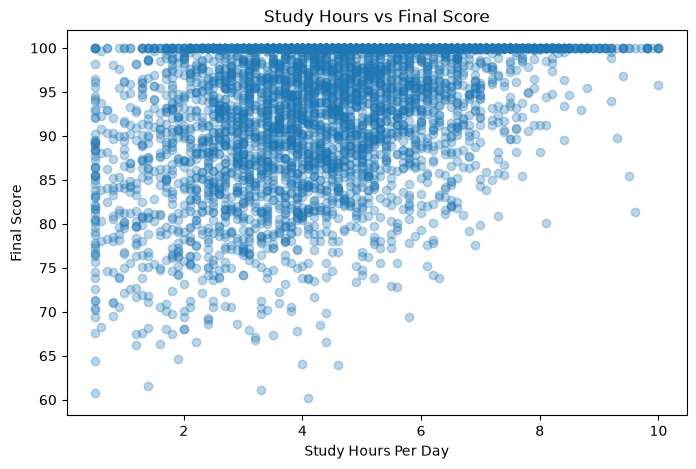

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Study_Hours_Per_Day'], df['Final_Score'], alpha=0.3)
plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Score')
plt.title('Study Hours vs Final Score')
plt.show()

In [5]:
X = df.drop(columns=['Final_Score'])
y = df['Final_Score']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_processed = preprocessor.fit_transform(X)
print('Processed feature count:', X_processed.shape[1])

C:\Users\ROHITH DASARI\AppData\Local\Temp\ipykernel_13788\1944613396.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


Processed feature count: 21


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (4000, 21)
X_test: (1000, 21)


In [7]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=1
)

Epoch 1/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 6045.3574 - mae: 74.3311 - val_loss: 408.1873 - val_mae: 17.9769
Epoch 2/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 159.1691 - mae: 9.8618 - val_loss: 58.8101 - val_mae: 6.1851
Epoch 3/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 110.4195 - mae: 8.3375 - val_loss: 47.0229 - val_mae: 5.4326
Epoch 4/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 104.9157 - mae: 8.1338 - val_loss: 44.7697 - val_mae: 5.3973
Epoch 5/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 95.2089 - mae: 7.7407 - val_loss: 39.1759 - val_mae: 4.9825
Epoch 6/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 89.9754 - mae: 7.5606 - val_loss: 35.5043 - val_mae: 4.7347
Epoch 7/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 80.4261 - mae: 7.1856 - val_loss: 34.2889 - val_mae: 4.7306
Epoch 8/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 80.9462 - mae: 7.1780 - val_loss: 31.3809 - val_mae: 4.3883
Epoch 9/80
100/100 ━━━━━━━━━━━━━

In [9]:
predictions = model.predict(X_test, verbose=0).flatten()
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f'MAE : {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²  : {r2:.3f}')

MAE : 3.69
RMSE: 4.68
R²  : 0.604


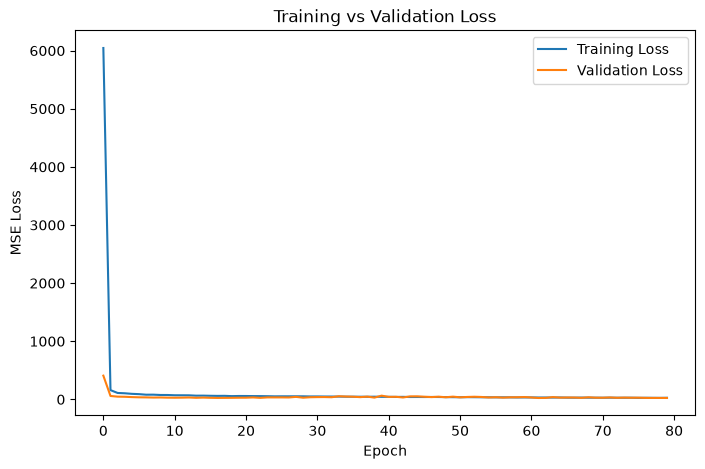

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

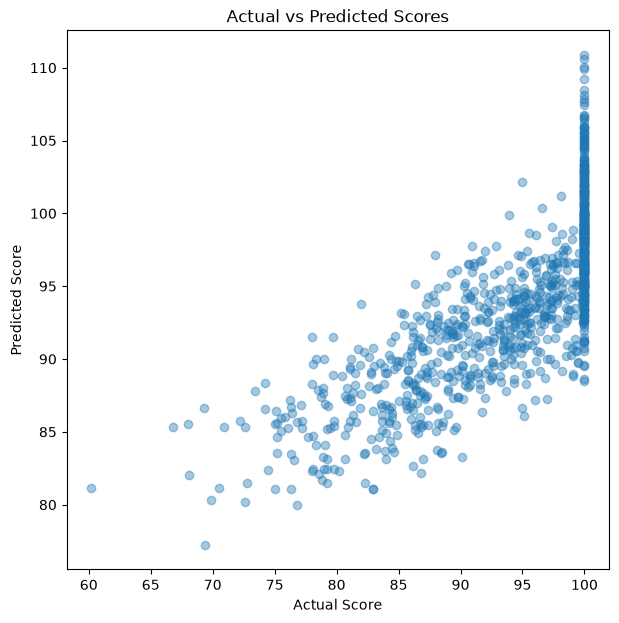

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, predictions, alpha=0.4)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted Scores')
plt.show()

In [12]:
model.save('student_performance_model.keras')
joblib.dump(preprocessor, 'preprocessor.pkl')

print('Saved: student_performance_model.keras')
print('Saved: preprocessor.pkl')

Saved: student_performance_model.keras
Saved: preprocessor.pkl


## User Input Prediction
The next cell lets you enter one student's details and predicts the final score.

In [14]:
user = pd.DataFrame([{
    'Attendance_Percentage': 90,
    'Study_Hours_Per_Day': 6,
    'Previous_Semester_Marks': 82,
    'Assignments_Completed': 9,
    'Sleep_Hours': 8,
    'Internet_Access': 'Yes',
    'Extra_Curricular_Activities': 'No',
    'Parental_Education': 'Bachelor',
    'Class_Participation': 8,
    'Mock_Tests_Attended': 6,
    'Disciplinary_Records': 0,
    'Family_Income': 'Middle',
    'Distance_From_College_KM': 6,
    'Age': 19
}])

user_processed = preprocessor.transform(user)
score = float(model.predict(user_processed, verbose=0)[0][0])
score = np.clip(score, 0, 100)
print(f'Predicted Final Score: {score:.2f}%')

Predicted Final Score: 100.00%


In [15]:
import pandas as pd

df = pd.read_csv("student_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (5000, 15)


,Attendance_Percentage,Study_Hours_Per_Day,Previous_Semester_Marks,Assignments_Completed,Sleep_Hours,Internet_Access,Extra_Curricular_Activities,Parental_Education,Class_Participation,Mock_Tests_Attended,Disciplinary_Records,Family_Income,Distance_From_College_KM,Age,Final_Score
0,87.5,3.7,58.5,7,7.4,Yes,No,Diploma,6,4,0,Middle,9.3,20,96.5
1,80.5,3.7,63.7,7,7.3,No,Yes,Bachelor,6,5,0,Middle,18.2,22,83.0
2,89.1,1.3,59.6,8,6.0,Yes,Yes,Diploma,5,3,0,Low,12.9,20,94.4
3,98.8,3.9,69.5,9,7.6,Yes,No,Bachelor,5,1,0,Low,8.7,20,100.0
4,79.4,5.8,84.8,6,5.4,Yes,Yes,Bachelor,8,1,0,Low,7.5,20,96.3


In [16]:
# Check dataset information
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Attendance_Percentage        5000 non-null   float64
 1   Study_Hours_Per_Day          5000 non-null   float64
 2   Previous_Semester_Marks      5000 non-null   float64
 3   Assignments_Completed        5000 non-null   int64  
 4   Sleep_Hours                  5000 non-null   float64
 5   Internet_Access              5000 non-null   str    
 6   Extra_Curricular_Activities  5000 non-null   str    
 7   Parental_Education           5000 non-null   str    
 8   Class_Participation          5000 non-null   int64  
 9   Mock_Tests_Attended          5000 non-null   int64  
 10  Disciplinary_Records         5000 non-null   int64  
 11  Family_Income                5000 non-null   str    
 12  Distance_From_College_KM     5000 non-null   float64
 13  Age     

In [17]:
# Separate features (X) and target (y)

X = df.drop("Final_Score", axis=1)
y = df["Final_Score"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print("Final_Score")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:
['Attendance_Percentage', 'Study_Hours_Per_Day', 'Previous_Semester_Marks', 'Assignments_Completed', 'Sleep_Hours', 'Internet_Access', 'Extra_Curricular_Activities', 'Parental_Education', 'Class_Participation', 'Mock_Tests_Attended', 'Disciplinary_Records', 'Family_Income', 'Distance_From_College_KM', 'Age']

Target:
Final_Score

X shape: (5000, 14)
y shape: (5000,)


In [18]:
# Identify numerical and categorical columns

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['Attendance_Percentage', 'Study_Hours_Per_Day', 'Previous_Semester_Marks', 'Assignments_Completed', 'Sleep_Hours', 'Class_Participation', 'Mock_Tests_Attended', 'Disciplinary_Records', 'Distance_From_College_KM', 'Age']

Categorical columns:
['Internet_Access', 'Extra_Curricular_Activities', 'Parental_Education', 'Family_Income']


C:\Users\ROHITH DASARI\AppData\Local\Temp\ipykernel_13788\308074684.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        ("categorical", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Original features:", X.shape[1])
print("Processed features:", X_processed.shape[1])

Original features: 14
Processed features: 21


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Input features:", X_train.shape[1])

Training samples: 4000
Testing samples: 1000
Input features: 21


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(16, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=1
)

Epoch 1/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 8266.8721 - mae: 90.5347 - val_loss: 6184.3926 - val_mae: 78.2887
Epoch 2/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1494.3864 - mae: 28.5422 - val_loss: 44.4541 - val_mae: 5.3063
Epoch 3/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 93.3272 - mae: 7.7197 - val_loss: 37.8115 - val_mae: 5.0405
Epoch 4/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 90.4856 - mae: 7.5630 - val_loss: 34.4287 - val_mae: 4.7172
Epoch 5/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 83.8568 - mae: 7.2806 - val_loss: 34.3758 - val_mae: 4.8118
Epoch 6/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 81.6756 - mae: 7.1853 - val_loss: 32.0944 - val_mae: 4.5615
Epoch 7/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 76.3562 - mae: 6.9271 - val_loss: 30.3518 - val_mae: 4.4278
Epoch 8/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 77.2320 - mae: 7.0122 - val_loss: 29.2283 - val_mae: 4.3051
Epoch 9/80
100/100 ━━━━━━━━━━━━

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on test data
y_pred = model.predict(X_test).flatten()

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Model Evaluation
-------------------------
MAE  : 3.21
RMSE : 4.27
R² Score : 0.6708


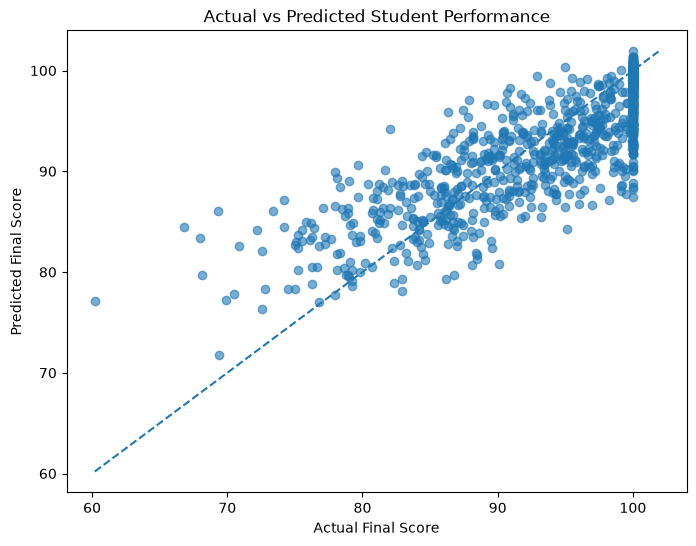

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Student Performance")

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

In [25]:
model.save("student_performance_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [26]:
import joblib

joblib.dump(preprocessor, "student_preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [29]:
import pandas as pd

# Example student input
student_input = pd.DataFrame([{
    "Attendance_Percentage":85,
    "Study_Hours_Per_Day": 4,
    "Previous_Semester_Marks": 72,
    "Assignments_Completed": 8,
    "Sleep_Hours": 7,
    "Internet_Access": "Yes",
    "Extra_Curricular_Activities": "Yes",
    "Parental_Education": "Bachelor",
    "Class_Participation": 8,
    "Mock_Tests_Attended": 5,
    "Disciplinary_Records": 0,
    "Family_Income": "Medium",
    "Distance_From_College_KM": 5,
    "Age": 20
}])

# Convert the input using the SAME preprocessor used during training
student_processed = preprocessor.transform(student_input)

# Predict final score
prediction = model.predict(student_processed, verbose=0)

predicted_score = float(prediction[0][0])

print("Student Performance Prediction")
print("--------------------------------")
print(f"Predicted Final Score: {predicted_score:.2f}")

# Performance category
if predicted_score >= 85:
    performance = "Excellent"
elif predicted_score >= 70:
    performance = "Good"
elif predicted_score >= 50:
    performance = "Average"
else:
    performance = "Needs Improvement"

print(f"Performance Level: {performance}")

Student Performance Prediction
--------------------------------
Predicted Final Score: 89.00
Performance Level: Excellent


In [ ]:
# Get student details from user

attendance = float(input("Enter Attendance Percentage: "))
study_hours = float(input("Enter Study Hours Per Day: "))
previous_marks = float(input("Enter Previous Semester Marks: "))
assignments = int(input("Enter Assignments Completed: "))
sleep_hours = float(input("Enter Sleep Hours: "))

internet = input("Internet Access (Yes/No): ")
extra_curricular = input("Extra Curricular Activities (Yes/No): ")
parental_education = input(
    "Parental Education (High School/Diploma/Bachelor/Master): "
)

participation = int(input("Enter Class Participation (0-10): "))
mock_tests = int(input("Enter Mock Tests Attended: "))
disciplinary = int(input("Enter Disciplinary Records: "))

family_income = input("Family Income (Low/Medium/High): ")

distance = float(input("Distance From College (KM): "))
age = int(input("Enter Age: "))


# Create DataFrame
student_input = pd.DataFrame([{
    "Attendance_Percentage": attendance,
    "Study_Hours_Per_Day": study_hours,
    "Previous_Semester_Marks": previous_marks,
    "Assignments_Completed": assignments,
    "Sleep_Hours": sleep_hours,
    "Internet_Access": internet,
    "Extra_Curricular_Activities": extra_curricular,
    "Parental_Education": parental_education,
    "Class_Participation": participation,
    "Mock_Tests_Attended": mock_tests,
    "Disciplinary_Records": disciplinary,
    "Family_Income": family_income,
    "Distance_From_College_KM": distance,
    "Age": age
}])

# Preprocess
student_processed = preprocessor.transform(student_input)

# Prediction
prediction = model.predict(student_processed, verbose=0)

predicted_score = float(prediction[0][0])

print("\n==============================")
print(" STUDENT PERFORMANCE RESULT")
print("==============================")
print(f"Predicted Final Score: {predicted_score:.2f}")

if predicted_score >= 85:
    print("Performance: Excellent")
elif predicted_score >= 70:
    print("Performance: Good")
elif predicted_score >= 50:
    print("Performance: Average")
else:
    print("Performance: Needs Improvement")